### 1. Setup and Parameters
Importing the required libraries 

Defining the constraints for our model

Parameters: budget limits, maximum assignments per helicopter, and helicopter specifications (cost and water capacity)


In [5]:
import pandas as pd
import geopandas as gpd
import time as tm

BUDGET = 311
MAX_ASSIGNMENTS_PER_HELI = 20
MAX_STATION_CAPACITY = 1
DISTANCE_LIMIT_KM = 150.0

HELI_TYPES = {
    1: {"name": "Type_1", "cost": 30, "water": 700},
    2: {"name": "Type_2", "cost": 10, "water": 300},
    3: {"name": "Type_3", "cost": 4, "water": 180},
}


### 2. Data Loading the datas
Loading the geospatial data (stations, water sources, and fire grids)

Calculating the minimum distances to water sources and constructs the distance matrix ($D_{i,j}$) between stations and fire grids

In [6]:


def load_data():
    df_risk = pd.read_csv("Rj_Risk_Matrix.csv")
    grid_ids = sorted(df_risk["Grid_ID"].unique())
    risk_by_grid = df_risk.set_index("Grid_ID")["R_j"].to_dict()

    gdf_stations = gpd.read_file(
        "cleaned_data/helipads_clean.geojson", on_invalid="ignore"
    )
    station_ids = sorted(gdf_stations["Station_ID"].unique())

    gdf_su = gpd.read_file(
        "cleaned_data/water_clean.geojson", on_invalid="ignore"
    ).to_crs(epsg=32635)
    gdf_stations = gdf_stations.to_crs(epsg=32635)

    df_grid = pd.read_csv("Grid_Coordinates.csv")
    gdf_grid = gpd.GeoDataFrame(
        df_grid, geometry=gpd.points_from_xy(df_grid.lon, df_grid.lat), crs="EPSG:4326"
    ).to_crs(epsg=32635)

    istasyon_su_join = gpd.sjoin_nearest(
        gdf_stations, gdf_su, how="left", distance_col="s_i"
    )
    s_i_df = istasyon_su_join.groupby("Station_ID")["s_i"].min().reset_index()

    grid_su_join = gpd.sjoin_nearest(gdf_grid, gdf_su, how="left", distance_col="w_j")
    w_j_df = grid_su_join.groupby("Grid_ID")["w_j"].min().reset_index()

    alpha = 5
    dist_by_pair = {}
    for i_row in s_i_df.itertuples():
        for j_row in w_j_df.itertuples():
            dist_by_pair[(i_row.Station_ID, j_row.Grid_ID)] = (
                i_row.s_i + (alpha + 1) * j_row.w_j
            ) / 1000.0

    return station_ids, grid_ids, risk_by_grid, dist_by_pair


### 3. Greedy + Local Search Algorithm
Implementing both Greedy and Local Search 

Greedy is used for sorting the  grids by highest risk ($R_j$) and assigns them to the closest feasible station using the cheapest available helicopter

Local Search is used for utilizing the remaining budget to upgrade helicopter types  to increasing water capacity and swaps grid assignments to closer active stations to minimize the total objective score

In [7]:

def solve_greedy_local_search(station_ids, grid_ids, risk_by_grid, dist_by_pair):
    start_time = tm.perf_counter()

    active_grids = [j for j in grid_ids if risk_by_grid.get(j, 0) > 0]
    sorted_grids = sorted(active_grids, key=lambda j: risk_by_grid[j], reverse=True)

    current_budget = BUDGET
    active_stations = {}
    grid_assignments = {}
    station_loads = {i: 0 for i in station_ids}

    for j in sorted_grids:
        feasible_stations = []
        for i in station_ids:
            d = dist_by_pair.get((i, j), float("inf"))
            if d <= DISTANCE_LIMIT_KM:
                feasible_stations.append((d, i))

        feasible_stations.sort(key=lambda x: x[0])

        for d, i in feasible_stations:
            if i in active_stations:
                if station_loads[i] < MAX_ASSIGNMENTS_PER_HELI:
                    grid_assignments[j] = i
                    station_loads[i] += 1
                    break
            else:
                cheapest_cost = HELI_TYPES[3]["cost"]
                if current_budget >= cheapest_cost:
                    active_stations[i] = 3 
                    current_budget -= cheapest_cost
                    grid_assignments[j] = i
                    station_loads[i] += 1
                    break

    for i in list(active_stations.keys()):
        current_type = active_stations[i]
        for target_type in [1, 2]:
            if current_type > target_type:
                upgrade_cost = (
                    HELI_TYPES[target_type]["cost"] - HELI_TYPES[current_type]["cost"]
                )
                if current_budget >= upgrade_cost:
                    active_stations[i] = target_type
                    current_budget -= upgrade_cost
                    break

    improved = True
    while improved:
        improved = False
        for j in list(grid_assignments.keys()):
            current_i = grid_assignments[j]
            current_d = dist_by_pair.get((current_i, j), float("inf"))

            best_new_i = None
            best_new_d = current_d

            for i in active_stations:
                if i != current_i and station_loads[i] < MAX_ASSIGNMENTS_PER_HELI:
                    new_d = dist_by_pair.get((i, j), float("inf"))
                    if new_d < best_new_d:
                        best_new_d = new_d
                        best_new_i = i

            if best_new_i is not None:
                grid_assignments[j] = best_new_i
                station_loads[current_i] -= 1
                station_loads[best_new_i] += 1
                improved = True

    end_time = tm.perf_counter()

    total_dist_risk = 0.0
    for j, i in grid_assignments.items():
        total_dist_risk += risk_by_grid[j] * dist_by_pair[(i, j)]

    unreachable_risk = sum(
        risk_by_grid[j] for j in sorted_grids if j not in grid_assignments
    )
    total_water = sum(HELI_TYPES[active_stations[i]]["water"] for i in active_stations)
    total_spent = BUDGET - current_budget

    objective_score = (
        total_dist_risk + (unreachable_risk * 1000) - (0.001 * total_water)
    )

    return {
        "time": end_time - start_time,
        "score": objective_score,
        "spent": total_spent,
        "water": total_water,
        "active_stations": active_stations,
        "assigned_grids": len(grid_assignments),
        "unreachable_grids": len(sorted_grids) - len(grid_assignments),
        "dist_risk": total_dist_risk,
    }


In [8]:
if __name__ == "__main__":
    st_ids, gr_ids, r_dict, d_pair = load_data()
    res = solve_greedy_local_search(st_ids, gr_ids, r_dict, d_pair)

    print("              GREEDY + LOCAL SEARCH RESULT              ")
    
    print(f"Computing Time        : {res['time']:.5f} seconds")
    print(f"Total Money Spent     : {res['spent']} Million  (Limit= 311)")
    print(f"Total Water Capacity  : {res['water']} Gallons")
    print(f"Active Station Count  : {len(res['active_stations'])}")
    print(f"Assigned Grids        : {res['assigned_grids']}")
    print(f"Best Objective Score  : {res['score']:.2f}")
    

    print("  HELICOPTER ALLOCATION")
    print(f"  {'Station':<10} {'Type':<10} {'Water (gal)':<14} {'Cost ($M)'}")

    sorted_stations = sorted(res["active_stations"].items())
    type_counts = {"Type_1": 0, "Type_2": 0, "Type_3": 0}

    for st_id, h_type in sorted_stations:
        h_info = HELI_TYPES[h_type]
        h_name = h_info["name"]
        w = h_info["water"]
        c = h_info["cost"]
        
        print(f"  {st_id:<10} {h_name:<10} {w:<14} {c}")
        type_counts[h_name] += 1

    print("\n")
    print("  SUMMARY BY TYPE")
    print(f"  Type_1    : {type_counts['Type_1']} Units")
    print(f"  Type_2 : {type_counts['Type_2']} Units")
    print(f"  Type_3  : {type_counts['Type_3']} Units")

              GREEDY + LOCAL SEARCH RESULT              
Computing Time        : 0.09593 seconds
Total Money Spent     : 306 Million  (Limit= 311)
Total Water Capacity  : 7620 Gallons
Active Station Count  : 15
Assigned Grids        : 294
Best Objective Score  : 1139.58
  HELICOPTER ALLOCATION
  Station    Type       Water (gal)    Cost ($M)
  0          Type_3     180            4
  2          Type_1     700            30
  4          Type_3     180            4
  10         Type_1     700            30
  13         Type_1     700            30
  22         Type_3     180            4
  28         Type_1     700            30
  38         Type_1     700            30
  54         Type_1     700            30
  79         Type_3     180            4
  87         Type_1     700            30
  98         Type_1     700            30
  174        Type_2     300            10
  175        Type_2     300            10
  177        Type_1     700            30


  SUMMARY BY TYPE
  Type_1  


### VISUALAZATION



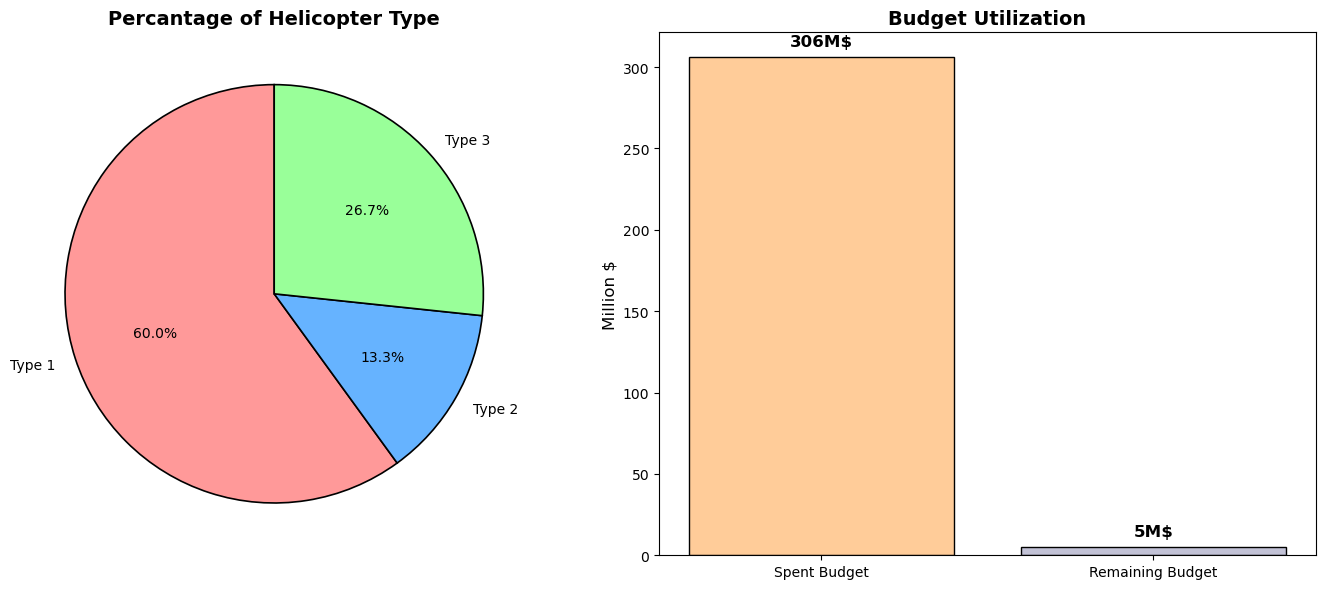

In [9]:
import matplotlib.pyplot as plt

labels = ["Type 1", "Type 2", "Type 3 "]
counts = [type_counts['Type_1'], type_counts['Type_2'], type_counts['Type_3']]
colors = ['#ff9999', '#66b3ff', '#99ff99']


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.pie(counts, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors, 
        wedgeprops={'edgecolor': 'black', 'linewidth': 1.2})
ax1.set_title('Percantage of Helicopter Type', fontweight='bold', fontsize=14)

budget_labels = ['Spent Budget', 'Remaining Budget']
budget_values = [res['spent'], BUDGET - res['spent']]
bars = ax2.bar(budget_labels, budget_values, color=['#ffcc99', '#c2c2d6'], edgecolor='black')
ax2.set_ylabel('Million $', fontsize=12)
ax2.set_title('Budget Utilization', fontweight='bold', fontsize=14)


for bar in bars:
    yval = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, yval + 5, f"{int(yval)}M$", 
             ha='center', va='bottom', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

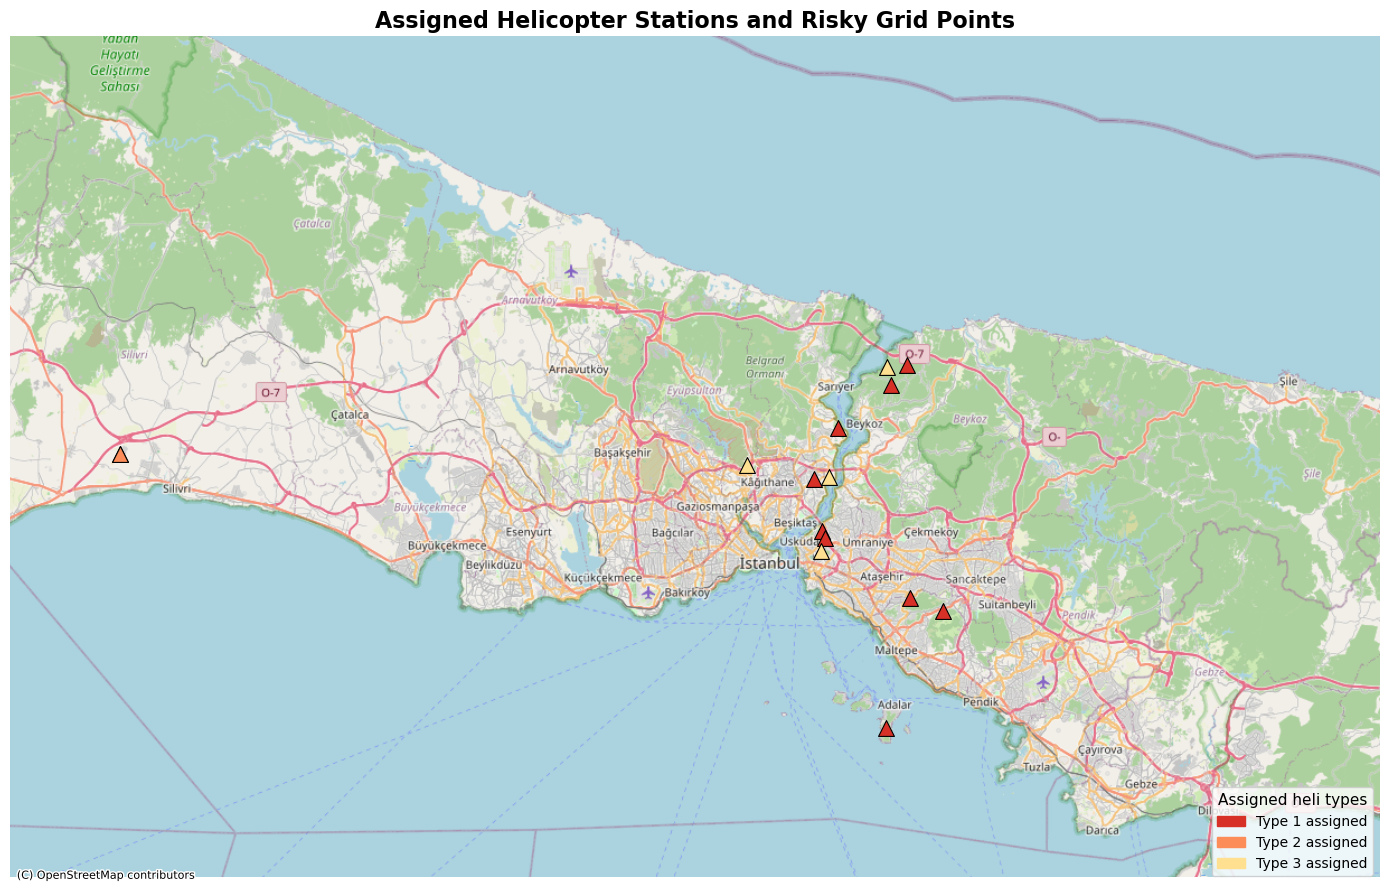

In [10]:
import contextily as ctx
import matplotlib.patches as mpatches

# Map integer heli type keys (1/2/3) to string names used for colors
type_name_map = {1: 'Type_1', 2: 'Type_2', 3: 'Type_3'}

# Load risk data directly to get risky grid IDs
df_risk = pd.read_csv('Rj_Risk_Matrix.csv')
risk_by_grid = df_risk.set_index('Grid_ID')['R_j'].to_dict()

# Load station geodata and grid coordinates
gdf_stations_map = gpd.read_file('cleaned_data/helipads_clean.geojson', on_invalid='ignore').to_crs(epsg=4326)
df_grid = pd.read_csv('Grid_Coordinates.csv')
gdf_grid_map = gpd.GeoDataFrame(
    df_grid,
    geometry=gpd.points_from_xy(df_grid.lon, df_grid.lat),
    crs='EPSG:4326',
)

# Filter to only the risky grid cells
active_grids = [j for j, r in risk_by_grid.items() if r > 0]
gdf_risky_grids = gdf_grid_map[gdf_grid_map['Grid_ID'].isin(active_grids)].copy()

# Get stations that were assigned a helicopter in the greedy solution
assigned_station_ids = list(res['active_stations'].keys())
gdf_assigned = gdf_stations_map[gdf_stations_map['Station_ID'].isin(assigned_station_ids)].copy()

if gdf_assigned.empty:
    print('No stations were assigned a helicopter.')
else:
    # Map each assigned station to its helicopter type name
    gdf_assigned['heli_type'] = gdf_assigned['Station_ID'].map(
        {i: type_name_map[h] for i, h in res['active_stations'].items()}
    )

    type_colors = {
        'Type_1': '#d73027',
        'Type_2': '#fc8d59',
        'Type_3': '#fee090',
    }
    gdf_assigned['color'] = gdf_assigned['heli_type'].map(type_colors)

    # Reproject to Web Mercator (EPSG:3857) for basemap compatibility
    gdf_risky_grids_3857 = gdf_risky_grids.to_crs(epsg=3857)
    gdf_assigned_3857 = gdf_assigned.to_crs(epsg=3857)

    fig, ax = plt.subplots(figsize=(14, 10))

    # Draw risky grid cells as light grey background points
    gdf_risky_grids_3857.plot(
        ax=ax, color='lightgrey', markersize=8,
        alpha=0.35, edgecolor=None, zorder=1,
    )

    # Draw assigned stations as triangles, one layer per helicopter type
    for heli_type, color in type_colors.items():
        mask = gdf_assigned_3857['heli_type'] == heli_type
        if mask.any():
            gdf_assigned_3857[mask].plot(
                ax=ax, marker='^', color=color,
                edgecolor='black', linewidth=0.8,
                markersize=130, label=heli_type, zorder=5,
            )

    ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik, zoom=10)

    bounds = pd.concat([gdf_risky_grids_3857.geometry, gdf_assigned_3857.geometry]).total_bounds
    xmin, ymin, xmax, ymax = bounds
    margin = 15000
    ax.set_xlim(xmin - margin, xmax + margin)
    ax.set_ylim(ymin - margin, ymax + margin)

    ax.set_title('Assigned Helicopter Stations and Risky Grid Points', fontweight='bold', fontsize=16)
    ax.axis('off')

    legend_handles = [
        mpatches.Patch(color=type_colors['Type_1'], label='Type 1 assigned'),
        mpatches.Patch(color=type_colors['Type_2'], label='Type 2 assigned'),
        mpatches.Patch(color=type_colors['Type_3'], label='Type 3 assigned'),
    ]
    plt.legend(handles=legend_handles, title='Assigned heli types',
               loc='lower right', fontsize=10, title_fontsize=11)
    plt.tight_layout()
    plt.show()